In [ ]:



import pandas as pd
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")
# for c in master_file.columns:
#     print(c)

master_file_clean = master_file.dropna(subset=["FINAL CONFIDENCE GRADING"])

master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

# print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
print('original grade oridinal counts:')
print(master_file_clean['grade_ordinal'].value_counts().sort_index())
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])
print('dropped na grade oridinal counts:')
print(master_file_clean['grade_ordinal'].value_counts().sort_index())


# remove duplicates
# master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])

# keep only necessary columns
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "grade_ordinal",
    "PPV_SOLO_DATASET ALL"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# # --- Check how many fell through to unknown ---
# print(one_hot_df['mut_type'].value_counts())
# unknown_mask = one_hot_df['mut_type'] == 'unknown'
# print(f"\n{unknown_mask.sum()} unparsed mutations:")
# for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
#     print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])

# Adding drug embedding columns
embedding_columns_list = [f'drug_embedding_{i}' for i in range(len(drug_embeddings['Amikacin']))]
one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()

# hold out Amikacin and Kanamycin for testing
holdout_drugs = ['Amikacin', 'Kanamycin']
test_df = one_hot_df[one_hot_df['drug'].isin(holdout_drugs)].copy()
train_df = one_hot_df[~one_hot_df['drug'].isin(holdout_drugs)].copy()

one_hot_df = one_hot_df.drop(columns=['drug', 'mutation'])
test_df = test_df.drop(columns=['drug', 'mutation'])
train_df = train_df.drop(columns=['drug', 'mutation'])

print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)
# print(one_hot_df.columns)

/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/874042194.py:180: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


original grade oridinal counts:
grade_ordinal
0      484
1    12379
2    33906
3     1130
4      253
Name: count, dtype: int64
dropped na grade oridinal counts:
grade_ordinal
0      484
1    12379
2    33906
3     1130
4      253
Name: count, dtype: int64


/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/874042194.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/874042194.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/874042194.py:239: PerformanceWarning: D

num features: 506
grade_ordinal
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertain
ref_*
ref_A
ref_C
ref_D
ref_E
ref_F
ref_G
ref_H
ref_I
ref_K
ref_L
ref_M
ref_N
ref_P


In [29]:
# remove rows with NaNs 
train_df = train_df.dropna()
test_df = test_df.dropna()


The curve rises steeply at first, indicating that the first several principal components capture most of the important information in the data, reaching roughly 70–75% explained variance within about the first 7–8 components. After around 10–15 components, the curve begins to level off, meaning additional components contribute progressively smaller amounts of new variance. This flattening, often called the “elbow,” suggests that keeping roughly 15–20 components provides a good trade-off between dimensionality reduction and information preservation, since adding more components yields only marginal improvement.

grade_ordinal
0      484
1    12379
2    33906
3     1130
4      253
Name: count, dtype: int64
grade_ordinal
0      400
1    11679
2    30176
3     1114
4      238
Name: count, dtype: int64
grade_ordinal
0      84
1     700
2    3618
3       4
4       8
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.06      0.67      0.11       400
           1       0.99      0.98      0.99     11679
           2       1.00      0.83      0.90     30176
           3       0.77      0.85      0.81      1114
           4       0.22      0.93      0.35       238

    accuracy                           0.87     43607
   macro avg       0.61      0.85      0.63     43607
weighted avg       0.98      0.87      0.91     43607

Accuracy: 0.87


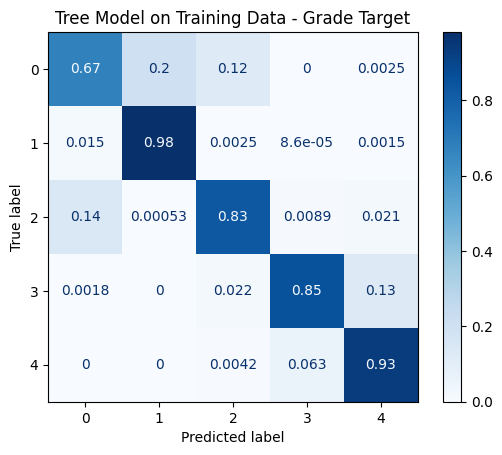

              precision    recall  f1-score   support

           0       0.05      0.31      0.09        84
           1       0.99      0.99      0.99       700
           2       0.98      0.86      0.92      3618
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         8

    accuracy                           0.87      4414
   macro avg       0.40      0.43      0.40      4414
weighted avg       0.96      0.87      0.91      4414

Accuracy: 0.87


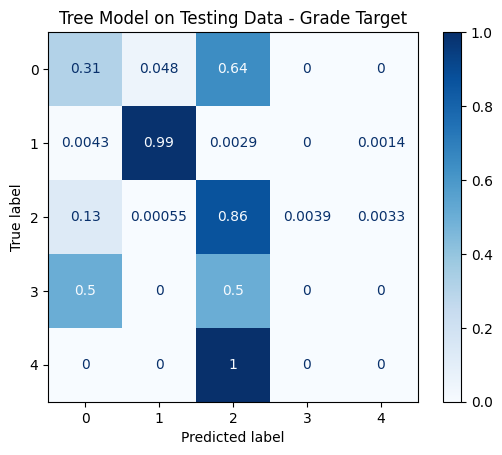

In [30]:

baseline_data = one_hot_df.copy()

print(one_hot_df['grade_ordinal'].value_counts().sort_index())


Xb_train = train_df.drop(columns=["grade_ordinal"])
Xb_test = test_df.drop(columns=["grade_ordinal"])
yb_train = train_df['grade_ordinal']
yb_test = test_df['grade_ordinal']

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=yb_train)

print(yb_train.value_counts().sort_index())
print(yb_test.value_counts().sort_index())

# x_base = x_base.fillna(0) # sometimes the inserts or deletes are not a number

from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(max_depth=5, random_state=0).fit(Xb_train, yb_train, sample_weight=sample_weights)

# predict resistance class
y_pred = clf.predict(Xb_train)

print(classification_report(yb_train, y_pred))

# Display the accuracy
accuracy = np.mean(yb_train == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_train, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Tree Model on Training Data - Grade Target")
plt.show()




from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(max_depth=5, random_state=0).fit(Xb_train, yb_train, sample_weight=sample_weights)

# predict resistance class
y_pred = clf.predict(Xb_test)

print(classification_report(yb_test, y_pred))

# Display the accuracy
accuracy = np.mean(yb_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Tree Model on Testing Data - Grade Target")
plt.show()


/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/3708036049.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/3708036049.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()
/var/folders/_h/ppym6hs50lx51lmb80t8l84m0000gq/T/ipykernel_91319/3708036049.py:26: PerformanceWarning: D

PPV_SOLO_DATASET ALL
0.000000    15335
0.004666        1
0.006369        1
0.006873        1
0.008621        1
            ...  
0.985537        1
0.987730        1
0.988139        1
0.992248        1
1.000000     1489
Name: count, Length: 371, dtype: int64
PPV_SOLO_DATASET ALL
0.000000    1939
0.008734       1
0.009174       1
0.009585       1
0.010830       1
            ... 
0.871287       1
0.925971       1
0.937500       1
0.949682       1
1.000000      58
Name: count, Length: 82, dtype: int64
MAE:  0.235
RMSE: 0.298
R²:   -0.010


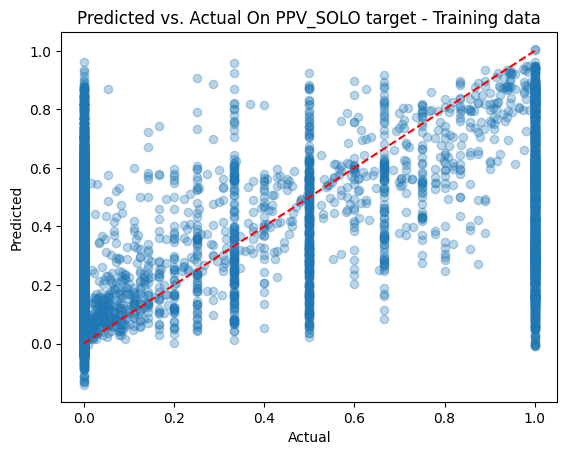

MAE:  0.357
RMSE: 0.399
R²:   -3.777


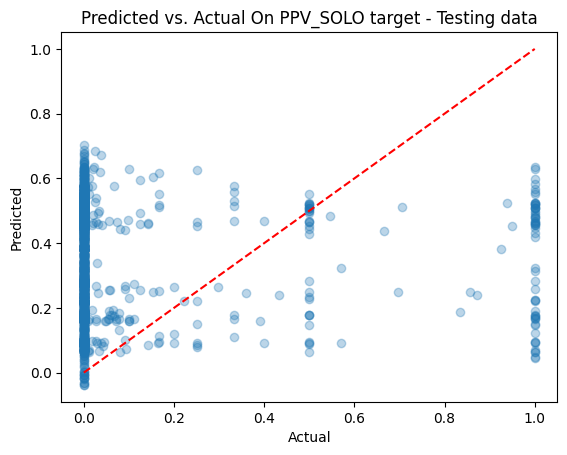

                      min       max  count
PPV_SOLO_binned                           
0                0.000000  0.166667  15709
1                0.171429  0.416667    363
2                0.421053  0.571429    353
3                0.581395  0.840000    296
4                0.851852  1.000000   1598
                      min       max  count
PPV_SOLO_binned                           
0                0.000000  0.166667   2027
1                0.200000  0.400000     25
2                0.433164  0.571429     35
3                0.666667  0.834532      4
4                0.857143  1.000000     63
PPV_SOLO_binned
0    15709
1      363
2      353
3      296
4     1598
Name: count, dtype: int64
PPV_SOLO_binned
0    2027
1      25
2      35
3       4
4      63
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     15709
           1       0.12      0.42      0.19       363
           2       0.16      0.49      0.24   

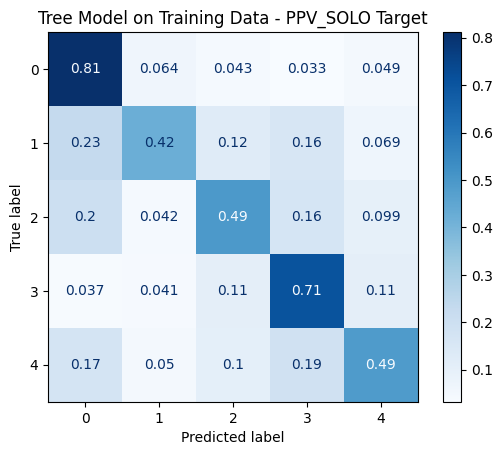

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      2027
           1       0.05      0.04      0.04        25
           2       0.01      0.14      0.03        35
           3       0.01      0.25      0.02         4
           4       0.00      0.00      0.00        63

    accuracy                           0.73      2154
   macro avg       0.20      0.24      0.19      2154
weighted avg       0.89      0.73      0.80      2154



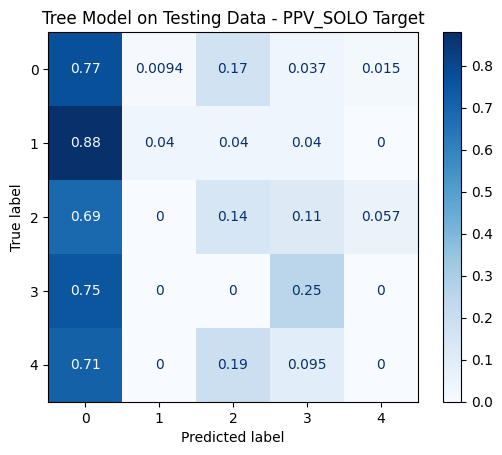

In [40]:
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "PPV_SOLO_DATASET ALL"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# # --- Check how many fell through to unknown ---
# print(one_hot_df['mut_type'].value_counts())
# unknown_mask = one_hot_df['mut_type'] == 'unknown'
# print(f"\n{unknown_mask.sum()} unparsed mutations:")
# for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
#     print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])

# Adding drug embedding columns
embedding_columns_list = [f'drug_embedding_{i}' for i in range(len(drug_embeddings['Amikacin']))]
one_hot_df[embedding_columns_list] = one_hot_df['drug'].map(drug_embeddings).tolist()

# hold out Amikacin and Kanamycin for testing
holdout_drugs = ['Amikacin', 'Kanamycin']
test_df = one_hot_df[one_hot_df['drug'].isin(holdout_drugs)].copy()
train_df = one_hot_df[~one_hot_df['drug'].isin(holdout_drugs)].copy()

one_hot_df = one_hot_df.drop(columns=['drug', 'mutation'])
test_df = test_df.drop(columns=['drug', 'mutation'])
train_df = train_df.drop(columns=['drug', 'mutation'])
train_df = train_df.dropna()
test_df = test_df.dropna()


Xb_train = train_df.drop(columns=["PPV_SOLO_DATASET ALL"])
Xb_test = test_df.drop(columns=["PPV_SOLO_DATASET ALL"])
yb_train = train_df['PPV_SOLO_DATASET ALL']
yb_test = test_df['PPV_SOLO_DATASET ALL']

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=yb_train)

print(yb_train.value_counts().sort_index())
print(yb_test.value_counts().sort_index())

# x_base = x_base.fillna(0) # sometimes the inserts or deletes are not a number

from sklearn.ensemble import HistGradientBoostingRegressor
clf = HistGradientBoostingRegressor(max_depth=5, random_state=0).fit(Xb_train, yb_train, sample_weight=sample_weights)

# predict resistance class
y_pred = clf.predict(Xb_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"MAE:  {mean_absolute_error(yb_train, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yb_train, y_pred)):.3f}")
print(f"R²:   {r2_score(yb_train, y_pred):.3f}")


plt.scatter(yb_train, y_pred, alpha=0.3)
plt.plot([yb_train.min(), yb_train.max()], [yb_train.min(), yb_train.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs. Actual On PPV_SOLO target - Training data")
plt.show()


# predict resistance class
y_pred = clf.predict(Xb_test)

print(f"MAE:  {mean_absolute_error(yb_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yb_test, y_pred)):.3f}")
print(f"R²:   {r2_score(yb_test, y_pred):.3f}")


plt.scatter(yb_test, y_pred, alpha=0.3)
plt.plot([yb_test.min(), yb_test.max()], [yb_test.min(), yb_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs. Actual On PPV_SOLO target - Testing data")
plt.show()





bins = [0, 0.17, 0.42, 0.58, 0.84, 1.0]
labels = [0, 1, 2, 3, 4]
train_df['PPV_SOLO_binned'] = pd.cut(train_df['PPV_SOLO_DATASET ALL'], bins=bins, labels=labels, include_lowest=True).astype(int)
test_df['PPV_SOLO_binned'] = pd.cut(test_df['PPV_SOLO_DATASET ALL'], bins=bins, labels=labels, include_lowest=True).astype(int)
print(train_df.groupby('PPV_SOLO_binned')['PPV_SOLO_DATASET ALL'].agg(['min', 'max', 'count']))
print(test_df.groupby('PPV_SOLO_binned')['PPV_SOLO_DATASET ALL'].agg(['min', 'max', 'count']))



Xb_train = train_df.drop(columns=["PPV_SOLO_DATASET ALL", "PPV_SOLO_binned"])
Xb_test = test_df.drop(columns=["PPV_SOLO_DATASET ALL", "PPV_SOLO_binned"])
yb_train = train_df['PPV_SOLO_binned'].fillna(2)
yb_test = test_df['PPV_SOLO_binned'].fillna(2)

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=yb_train)

print(yb_train.value_counts().sort_index())
print(yb_test.value_counts().sort_index())

# x_base = x_base.fillna(0) # sometimes the inserts or deletes are not a number

from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(max_depth=5, random_state=0).fit(Xb_train, yb_train, sample_weight=sample_weights)

# predict resistance class
y_pred = clf.predict(Xb_train)

print(classification_report(yb_train, y_pred))

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_train, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Tree Model on Training Data - PPV_SOLO Target")
plt.show()



# predict resistance class
y_pred = clf.predict(Xb_test)
print(classification_report(yb_test, y_pred))

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(yb_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Tree Model on Testing Data - PPV_SOLO Target")
plt.show()




<Axes: >

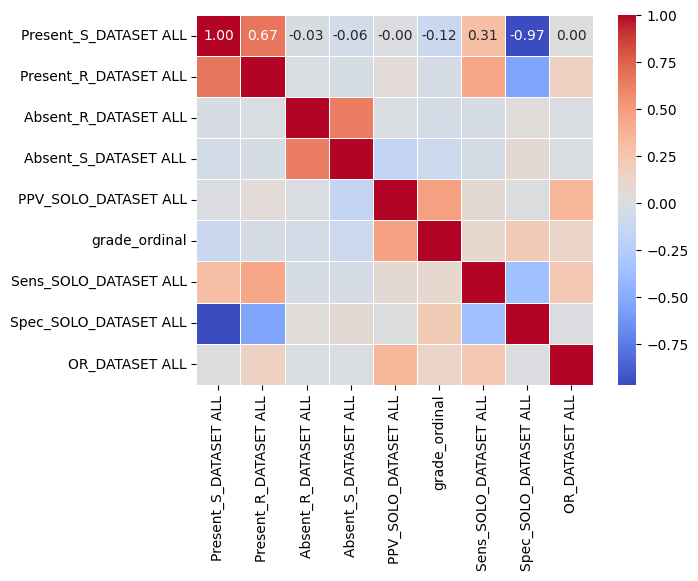

In [44]:
mf_clean = master_file_clean.copy()
# print(mf_clean.columns[:60])

columns_to_compare = ['Present_S_DATASET ALL', 'Present_R_DATASET ALL', 'Absent_R_DATASET ALL', 'Absent_S_DATASET ALL', 'PPV_SOLO_DATASET ALL', 'grade_ordinal', 'Sens_SOLO_DATASET ALL', 'Spec_SOLO_DATASET ALL', 'OR_DATASET ALL']
mf_clean = mf_clean[columns_to_compare]
sns.heatmap(mf_clean.corr(), annot=True, fmt=".2f", linewidths=0.5, cmap="coolwarm")